In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np

# Load the saved data from the .mat file
data_file_path = 'Dp_current_clamp_example13.mat'
mat_data = sio.loadmat(data_file_path)

# Extract variables from the loaded .mat file
data_matrix = mat_data['dataMatrix']
color_matrix = mat_data['colorMatrix']
x_data = mat_data['xData'].flatten()  # Assuming xData is a 1D array, flatten it
line_widths = mat_data['lineWidths'].flatten()  # Assuming lineWidths is a 1D array, flatten it


In [12]:
data_matrix.shape

(11, 380000)

In [13]:
data_matrix
import pandas as pd
# Convert the data matrix to dataframe. The row index is (fit, mean, trial 1 to trial 9). The column is time as x_data
df = pd.DataFrame(data_matrix, index=['fit', 'mean'] + [f'trial {i+1}' for i in range(data_matrix.shape[0]-2)], columns=x_data)

import os
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure03')
os.makedirs(save_dir, exist_ok=True)
df.to_csv(os.path.join(save_dir, 'extended_figure03g_example_neuron_membrane_potential.csv'))

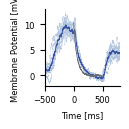

In [14]:

# Plot the data matrix in reverse order as per the original MATLAB code
figsize = (1.4,1.4)
fontsize = 6
fig, ax = plt.subplots(figsize=figsize)
reversed_idx = range(data_matrix.shape[0] - 1, -1, -1)  # Create reversed indices similar to MATLAB's `10:-1:1`

for idx in reversed_idx:
    if idx == 0:
        color = '#6D6E71'# '#ED1F24'
    elif idx == 1:
        color = '#3953A4'
    else:
        color = 'lightsteelblue'
    ax.plot(x_data, data_matrix[idx, :], color=color, linewidth=line_widths[idx]*0.3)

# Set x-axis limits as per the MATLAB code
ax.set_xlim([-500, 800])

# Display the plot
ax.set_xlabel('Time [ms]', fontsize=fontsize)
ax.set_ylabel('Membrane Potential [mV]', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)

ax.set_ylim(-2, 13)
from catrace.visualize import set_yticks_interval
set_yticks_interval(ax, 5)

# Despine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

from catrace.for_paper import save_figure_for_paper
fig_dir = '../../figures_for_paper'
fig_name = 'Dp_current_clamp_example13'
save_figure_for_paper(fig, fig_name, fig_dir)